
# Experiment 02 — Adversarial Attack & Defense Evaluation

**Research context**  
This notebook investigates the robustness of deep learning vision models under gradient‑based adversarial attacks (FGSM, PGD) and evaluates the effectiveness of multiple defensive strategies including adversarial training and input detection.

**Experimental objective**
- Quantify baseline model vulnerability
- Measure degradation under adaptive attacks
- Evaluate detection tradeoffs (TPR / FPR)
- Analyze operational security implications

**Execution environment**
Results were produced on a CPU‑based research workstation (PyTorch runtime).  
Reproducibility depends on dataset version, random seeds, and batch sampling.


# Adversarial Robustness Research Series  Experiment 02: Detecting and Defending Against Adversarial Attacks on Machine Learning Models

This notebook is part of a continuous AI security experimentation track.
* Experimenr 01: Adversarial Examples in Practice_Breaking a Vision Model with FGSM
* <font color='violet'>Experimenr 02: Detecting and Defending Against Adversarial Attacks on Machine Learning Models</font>
* Experimenr 03: AI Assisted Cyber Threat Intelligence for Malware and Adversary Tracking

Series continuity
Experiment 01 introduced adversarial sample generation on CIFAR 10. 
Experiment 02 extends it with robustness evaluation, defenses, detection, and adaptive attacker analysis.
Experiment 01 is a project done as part of the Cyber Swiss Institute AI Security training (Experiment 01 template provided by SCI). The other experiments are a kind of suite of this one. the terms used, variables and style, including the organizations and steps of the code is maintained to facilititate the comphrehension of all the experiments.

High level structure used across the series:
* Baseline
* Attacks
* Defenses
* Detector
* Adaptive attacker
* FGSM vs PGD detection comparison
* Final comparison
* Security takeaways


## Environment notes

This run is executed on a Windows laptop (32gb ram, Intel 7) with Anaconda and Jupyter.
PyTorch is configured for CPU execution in this environment in order to be reproductible easily.
To keep the notebook runnable end to end on CPU, some evaluations use a limited number of batches.


# Detecting and Defending Against Adversarial Attacks on Machine Learning Models

In [ ]:
#######################################
# Author: Alphabot42                  # 
# Contributor: Laurent Mandine, lulu  #
# Python 3.11                         #
#######################################


import torch
print(torch.__version__)


2.10.0+cpu


# Part 1: Baseline ML pipeline

## Step 1: Dataset Preparation

In this step, we prepare the CIFAR-10 dataset, a widely used benchmark in computer vision and adversarial robustness research.

The dataset contains 60,000 images across 10 object categories.  
We apply normalization to ensure stable and efficient model training.


In [2]:
import torch
import torchvision#  computer vision
import torchvision.transforms as transforms# images transformation tools
from torch.utils.data import DataLoader#--> load data in batches during training/testing

# Preprocessing pipeline
transform = transforms.Compose([
    transforms.ToTensor(),                 # Convert to tensor
    transforms.Normalize((0.5, 0.5, 0.5),  # Normalize mean
                         (0.5, 0.5, 0.5))  # Normalize std
])


# Training dataset
trainset = torchvision.datasets.CIFAR10(
    root='../data',
    train=True,
    download=True,
    transform=transform
)

# Test dataset
testset = torchvision.datasets.CIFAR10(
    root='../data',
    train=False,
    download=True,
    transform=transform
)

# Data loaders
trainloader = DataLoader(trainset, batch_size=128, shuffle=True)
testloader  = DataLoader(testset, batch_size=128, shuffle=False)

# CIFAR-10 classes
classes = (
    'plane','car','bird','cat',
    'deer','dog','frog','horse',
    'ship','truck'
)

# Sample batch check
images, labels = next(iter(trainloader))
print(images.shape)


c:\Users\natyn\anaconda3\envs\advml\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


torch.Size([128, 3, 32, 32])


## Step 2: baseline CIFAR-10 model creation

Now that the dataset is loaded, we build a simple CNN baseline classifier.
This baseline will later be attacked using adversarial methods to evaluate robustness.

In [3]:
import torch.nn as nn
import torch.nn.functional as F

# Simple CNN baseline model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)   # conv layer Conv = feature extraction
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)  # conv layer
        self.pool = nn.MaxPool2d(2, 2)                 # max pooling  = downsampling + information compression
        self.fc1 = nn.Linear(64 * 8 * 8, 256)          # fully connected
        self.fc2 = nn.Linear(256, 10)                  # output layer

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))           # conv + relu + pool
        x = self.pool(F.relu(self.conv2(x)))           # conv + relu + pool
        x = x.view(x.size(0), -1)                      # flatten
        x = F.relu(self.fc1(x))                        # fc + relu
        x = self.fc2(x)                                # logits
        return x

model = SimpleCNN()
print(model)


SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


## Step 3: Model architecture visualization


In [4]:
pip install torchsummary


Note: you may need to restart the kernel to use updated packages.


In [5]:
from torchsummary import summary   # model summary tool

device = torch.device("cpu")       # running on CPU

model.to(device)

summary(model, (3, 32, 32))        # CIFAR-10 input shape



----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
         MaxPool2d-2           [-1, 32, 16, 16]               0
            Conv2d-3           [-1, 64, 16, 16]          18,496
         MaxPool2d-4             [-1, 64, 8, 8]               0
            Linear-5                  [-1, 256]       1,048,832
            Linear-6                   [-1, 10]           2,570
Total params: 1,070,794
Trainable params: 1,070,794
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.47
Params size (MB): 4.08
Estimated Total Size (MB): 4.57
----------------------------------------------------------------


Convolutional layers (Conv2D) apply learnable filters across the image to detect local visual patterns such as edges, textures, and shapes. As the network deepens, these filters learn increasingly complex features.

MaxPooling layers reduce the spatial dimensions of the feature maps by selecting the maximum value within small regions (e.g., 2x2). This operation decreases computational cost, improves robustness to small spatial variations, and helps the network focus on the most important features.

The baseline CNN architecture consists of two convolutional layers followed by fully connected layers for classification.

The model contains approximately 1.07 million trainable parameters, which is suitable for a CIFAR-10 baseline while remaining computationally manageable on CPU.

The output shapes confirm that spatial dimensions are progressively reduced through pooling operations before the final classification layer, which produces predictions across the 10 CIFAR-10 classes.



## Step 4: Training setup and helper functions

In this step, we prepare all components required for training the model.

We define:
- A loss function to measure classification error
- An optimizer to update model weights
- Training and evaluation loops
- Accuracy computation to monitor performance

> unlike in Experimenr 01: Adversarial Examples in Practice_Breaking a Vision Model with FGSM, we won't use model.fit(). We need model.fit() when we use Keras/TensorFlow but not with Pytorch.
Keras manage forward pass, loss, backward pass, optimizer, epochs and batches but with Pytorch we train manually

> <font color='red'>Why Pytorch and not Keras/TensorFlow? </font>
Training is implemented through explicit training loops, which provides full control over 
forward passes, gradient computation, adversarial input generation, and custom defense 
mechanisms. This flexibility is essential for adversarial machine learning research


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

# Select device (CPU is sufficient for this baseline)
device = torch.device("cpu")

# Move model to selected device
model = model.to(device)

# Loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# Optimizer updates model parameters during training
optimizer = optim.Adam(model.parameters(), lr=1e-3)


def compute_accuracy(logits, labels):
    preds = logits.argmax(dim=1)                     # predicted classes
    return (preds == labels).float().mean().item()   # accuracy value


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()                                    # enable training mode
    total_loss = 0.0
    total_accuracy = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()                        # reset gradients
        outputs = model(images)                      # forward pass
        loss = criterion(outputs, labels)            # compute loss
        loss.backward()                              # backward pass
        optimizer.step()                             # update weights

        total_loss += loss.item()
        total_accuracy += compute_accuracy(outputs, labels)

    return total_loss / len(loader), total_accuracy / len(loader)
# = model.fit() in Keras / TensorFlow

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()                                     # evaluation mode
    total_loss = 0.0
    total_accuracy = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item()
        total_accuracy += compute_accuracy(outputs, labels)

    return total_loss / len(loader), total_accuracy / len(loader)



Adversarial attacks do not modify the training loop itself.
Instead, they manipulate the input data that is fed into the forward pass, which is exactly where adversarial samples are injected into the model.

### verification

We run a single forward pass on one batch to ensure the model,
loss function, and training components are correctly configured.


In [8]:
model.eval()                                        # evaluation mode

images, labels = next(iter(trainloader))            # get one batch
images, labels = images.to(device), labels.to(device)

outputs = model(images)                             # forward pass
loss = criterion(outputs, labels)                   # compute loss
acc = compute_accuracy(outputs, labels)             # compute accuracy

print("Check OK")
print("Loss:", loss.item())
print("Accuracy:", acc)


Check OK
Loss: 2.3076069355010986
Accuracy: 0.09375


The initial loss (~2.30) and accuracy (~10%) indicate that the model is not yet trained
and is performing close to random guessing across the 10 CIFAR-10 classes.

This confirms that the data pipeline, model forward pass, loss computation,
and accuracy metric are correctly configured before starting training.


## Step 5: Baseline model training

We train the baseline CNN model on the CIFAR-10 dataset.
This baseline performance will later serve as a reference
to measure the impact of adversarial attacks.


In [9]:
num_epochs = 5

for epoch in range(num_epochs):
    
    model.train()                     # training mode
    
    running_loss = 0.0
    running_correct = 0
    total = 0
    
    for images, labels in trainloader:
        
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()         # reset gradients
        
        outputs = model(images)       # forward pass
        
        loss = criterion(outputs, labels)
        loss.backward()               # backward pass
        optimizer.step()              # update weights
        
        running_loss += loss.item()
        running_correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / len(trainloader)
    epoch_acc  = running_correct / total
    
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Accuracy: {epoch_acc:.4f}")


Epoch [1/5] Loss: 1.3688 Accuracy: 0.5092
Epoch [2/5] Loss: 0.9992 Accuracy: 0.6497
Epoch [3/5] Loss: 0.8448 Accuracy: 0.7019
Epoch [4/5] Loss: 0.7238 Accuracy: 0.7471
Epoch [5/5] Loss: 0.6125 Accuracy: 0.7857


> What do we observe?
*  Loss ↓ 
*  Accuracy ↑ 

## step6: Baseline accuracy evaluation and saving

We evaluate the trained baseline model on the test dataset and store the baseline accuracy. This value will later be used to measure the impact of adversarial attacks and defenses.


In [10]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        preds = outputs.argmax(1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)

baseline_accuracy = correct / total

print("Baseline Test Accuracy:", baseline_accuracy)


Baseline Test Accuracy: 0.7123


In [11]:
import os

os.makedirs("reports", exist_ok=True)

with open("reports/baseline_accuracy.txt", "w") as f:
    f.write(f"Baseline accuracy: {baseline_accuracy:.4f}")

print("Baseline accuracy saved in reports/baseline_accuracy.txt")


Baseline accuracy saved in reports/baseline_accuracy.txt


The baseline accuracy represents the normal performance of the model without adversarial perturbations. This metric will be used as the reference point to quantify the impact of adversarial attacks and to evaluate the effectiveness of defense mechanisms.

> important points:
* Baseline accuracy
* Accuracy under attack
* Accuracy after defense



# PArt2: Attacks

We now implement FGM and PGD attacks directly in Pytorch to understand how adverserial perturbations are generated fromthe gradientof the loss  with respect to the input image.

We implement FGSM and PGD because they are the most widely used baseline adversarial attacks in machine learning security research.
* <font color='blue'>FGSM → baseline attack</font>
* <font color='blue'>PGD → strong attack</font>


### FGSM attack implementation

FGSM generates adversarial examples by computing the gradient of the loss with respect to the input image and applying a single-step perturbation in the direction that maximizes the loss. The perturbation magnitude is controlled by epsilon.

Because the input images are normalized using `Normalize(0.5, 0.5, 0.5)`, the valid input range is approximately `[-1, 1]`, so we clamp adversarial images to this range.





In [12]:
import torch 
import torch.nn.functional as F  # loss functions

def fgsm_attack(model, images, labels, epsilon, device, debug=False):  # FGSM attack
    model.eval()  # eval mode

    images = images.to(device)  # move images to CPU computation
    labels = labels.to(device)  # move labels

    images_adv = images.clone().detach()  # copy original image -->future averserial images
    images_adv.requires_grad = True  # enable grad on input (alcul du gradient par rapport aux pixels.)

    outputs = model(images_adv)  # forward pass
    loss = F.cross_entropy(outputs, labels)  # compute loss

    model.zero_grad()  # clear model grads
    loss.backward()  # compute grad with respect to input.(gradient par rapport aux pixels d’entrée)
    #debug
    #print(images_adv.grad.abs().mean().item())  # grad mean. pour vérif.= id not null -->gratient ok
    if debug:  # debug print
        print("grad mean abs:", float(images_adv.grad.abs().mean().item()))
        
    grad_sign = images_adv.grad.sign()  # sign of gradient
    images_adv = images_adv + epsilon * grad_sign  # apply perturbation
    images_adv = torch.clamp(images_adv, -1.0, 1.0)  # clamp to valid range

    return images_adv.detach()  # return tensor without grad


In [13]:
import inspect
print("fgsm_attack object:", fgsm_attack)
print("fgsm_attack defined in:", inspect.getsourcefile(fgsm_attack))
print("fgsm_attack signature:", inspect.signature(fgsm_attack))


fgsm_attack object: <function fgsm_attack at 0x000001F4B8EBDDA0>
fgsm_attack defined in: C:\Users\natyn\AppData\Local\Temp\ipykernel_44252\2553432610.py
fgsm_attack signature: (model, images, labels, epsilon, device, debug=False)


In [14]:
images, labels = next(iter(testloader))
_ = fgsm_attack(model, images, labels, epsilon=0.03, device=device, debug=True)


grad mean abs: 0.00016975570179056376


#### FGSM attack visualization

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8980392..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9123529..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.030000001..0.030000001].


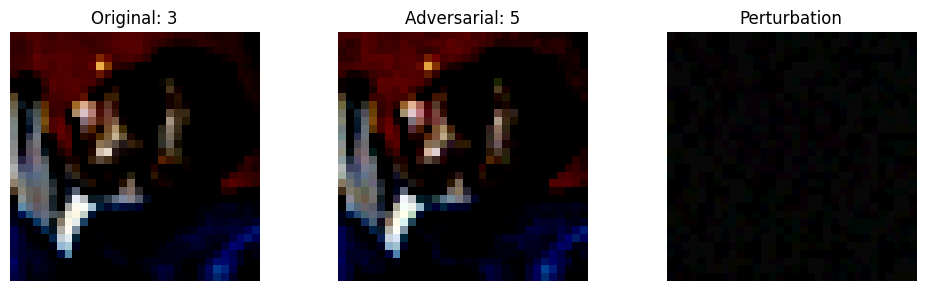

In [17]:
################################
#  Visualize the Perturbation  #
################################
import matplotlib.pyplot as plt 

model.eval()

epsilon = 0.03  # keep same epsilon 

images, labels = next(iter(testloader))
images, labels = images.to(device), labels.to(device)

# craft adversarial batch
images_adv = fgsm_attack(model, images, labels, epsilon=epsilon, device=device)

# take a single sample from the batch (index 0)
img = images[0:1]
img_adv = images_adv[0:1]

# predic
out_clean = model(img)
out_adv = model(img_adv)

pred_clean = out_clean.argmax(1).item()
pred_adv = out_adv.argmax(1).item()


delta = img_adv - img  # Compute pixel difference (perturbation)

fig, axs = plt.subplots(1, 3, figsize=(10, 3))

axs[0].imshow(img.squeeze().detach().permute(1,2,0).cpu())
axs[0].set_title(f'Original: {pred_clean}')
axs[0].axis('off')

axs[1].imshow(img_adv.squeeze().detach().permute(1,2,0).cpu())
axs[1].set_title(f'Adversarial: {pred_adv}')
axs[1].axis('off')

axs[2].imshow(delta.squeeze().detach().permute(1,2,0).cpu(), cmap='seismic', vmin=-epsilon, vmax=epsilon)
axs[2].set_title('Perturbation')
axs[2].axis('off')

plt.tight_layout()
plt.show()


#### Clean and adversarial evaluation helpers

We define evaluation helpers to measure accuracy on clean inputs and on adversarial inputs. This allows direct comparison between baseline performance and robustness under attack.


In [18]:
@torch.no_grad()
def evaluate_clean_accuracy(model, dataloader, device):  # clean eval
    model.eval()  # eval mode
    correct = 0  # correct count
    total = 0  # total count

    for images, labels in dataloader:  # batches
        images = images.to(device)  # to device - Maths must be on the same device
        labels = labels.to(device)  # to device

        outputs = model(images)  # forward
        preds = outputs.argmax(dim=1)  # prediction

        correct += (preds == labels).sum().item()  # correct
        total += labels.size(0)  # total

    return correct / total  # accurancy


def evaluate_fgsm_accuracy(model, dataloader, epsilon, device, max_batches=None):  # FGSM eval
    model.eval()  # eval mode
    correct = 0  # correct count
    total = 0  # total count

    for batch_idx, (images, labels) in enumerate(dataloader):  # batches
        if max_batches is not None and batch_idx >= max_batches:  # limit
            break

        with torch.enable_grad():  # enable grad for attack
            images_adv = fgsm_attack(model, images, labels, epsilon, device)  # adv imgs

        with torch.no_grad():  # no grad for eval forward
            labels = labels.to(device)  # to device
            outputs = model(images_adv)  # forward
            preds = outputs.argmax(dim=1)  # preds

        correct += (preds == labels).sum().item()  # correct
        total += labels.size(0)  # total

    return correct / total  # acc



#### FGSM robustness experiment

We measure baseline (clean) accuracy and then evaluate accuracy under FGSM for multiple epsilon values. We expect accuracy to drop as epsilon increases.


In [19]:
device = torch.device("cpu")  # CPU device

clean_acc = evaluate_clean_accuracy(model, testloader, device)  # clean acc
print("Clean accuracy:", round(clean_acc, 4))  # print

epsilons = [0.0, 0.01, 0.03, 0.05, 0.1]  # epsilon list (robustness progressively degradation)
"""
• 0.01 → very small perturbations, nearly imperceptible  
• 0.03 → commonly used robustness benchmark in adversarial ML research  
• 0.05 → stronger attack scenario representing more aggressive adversaries  
"""
for eps in epsilons[1:]:  # skip 0.0
    fgsm_acc = evaluate_fgsm_accuracy(model, testloader, eps, device, max_batches=50)  # quick eval
    print("FGSM epsilon:", eps, "| accuracy:", round(fgsm_acc, 4))  #


Clean accuracy: 0.7123
FGSM epsilon: 0.01 | accuracy: 0.4834
FGSM epsilon: 0.03 | accuracy: 0.1677
FGSM epsilon: 0.05 | accuracy: 0.0497
FGSM epsilon: 0.1 | accuracy: 0.0042


<font color='red'>FGSM attack conclusion</font>

The FGSM experiment confirms that the baseline CNN is highly vulnerable to gradient based adversarial perturbations. As the perturbation magnitude epsilon increases, classification accuracy drops sigificantly, even though the visual changes applied to the images remain small.

This behavior highlights a key property of deep neural networks: the learned feature space is sensitive to carefully crafted input perturbations aligned with the loss gradient. These results establish a baseline robustness measurement that will be used to compare stronger iterative attacks such as PGD and future defense mechanisms.

### PGD attack implementation

PGD (Projected Gradient Descent) extends FGSM by performing multiple small iterative gradient steps while projecting the perturbation back into an epsilon-bounded region around the original image. This makes PGD significantly stronger and often used as a worst-case robustness evaluation attack.

Here, the term "region" refers to the epsilon-bounded neighborhood around the original input.
This region defines the set of all valid adversarial samples whose pixel-wise perturbations remain within ±ε of the original image.

region = epsilon ball


In [20]:
import torch
import torch.nn.functional as F

def pgd_attack(model, images, labels, epsilon, alpha, steps, device, random_start=True, debug=False):
    model.eval()

    images = images.to(device)
    labels = labels.to(device)

    x_orig = images.detach()

    if random_start:
        x_adv = x_orig + torch.empty_like(x_orig).uniform_(-epsilon, epsilon)  # random init
        x_adv = torch.clamp(x_adv, -1.0, 1.0)  # keep valid range
    else:
        x_adv = x_orig.clone()

    for i in range(steps):
        x_adv = x_adv.clone().detach()
        x_adv.requires_grad = True  # enable input grad

        outputs = model(x_adv)  # forward
        loss = F.cross_entropy(outputs, labels)  # loss

        model.zero_grad()  # clear grads
        loss.backward()  # compute grad


        '''Le gradient indique dans quelle direction modifier chaque pixel pour augmenter la loss et tromper le modèle.
            Mais FGSM ne prend pas la valeur exacte du gradient, il prend seulement :
            +1 si le gradient est positif
            −1 si le gradient est négatif
            0 si 0 si gradient nul
           -->  pour chaque pixel, prends uniquement la direction de modification (augmenter ou diminuer), pas l’intensité.
           x_adv = x_adv + epsilon * grad_sign = ce qui crée la perturbation adversariale.
        '''
        grad_sign = x_adv.grad.sign()  # grad sign
        x_adv = x_adv + alpha * grad_sign  # step

        delta = torch.clamp(x_adv - x_orig, min=-epsilon, max=epsilon)  # project to eps ball (chaque pixel ne peut être modifié que de ±epsilon maximum par rapport à l image originale.)
        x_adv = torch.clamp(x_orig + delta, -1.0, 1.0)  # keep valid range (This projection guarantees that the adversarial sample remains a valid epsilon-bounded perturbation of the original input.)
        #calcule la perturbation delta
        #on coupe delta dans l intervalle [-epsilon, +epsilon]
        #on reconstruit l image adversariale autorisée

        if debug and i == 0:
            print("pgd step 1 grad mean abs:", float(x_adv.grad.abs().mean().item()) if x_adv.grad is not None else "None")

    return x_adv.detach()


Projecting to the epsilon ball" ensures that the adversarial example remains within an L∞ distance of epsilon from the original image(limit max pixel per pixel). After each gradient step, the perturbation is clipped so that every pixel change stays within [-epsilon, +epsilon], enforcing the constraint

#### PGD attack visualization

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8980392..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9039977..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.030000001..0.030000001].


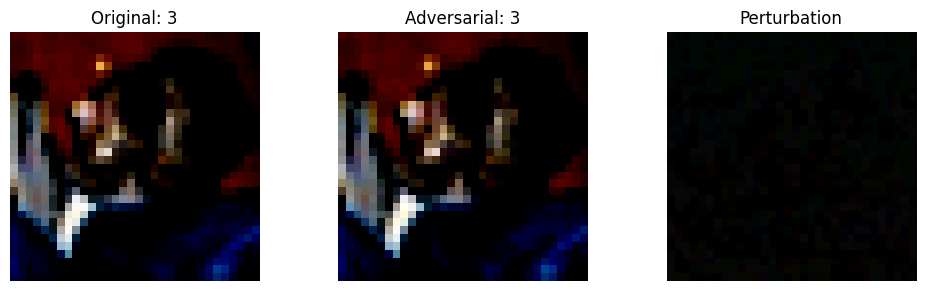

In [35]:
################################
#  Visualize the Perturbation  #
################################

img = images[0:1].to(device)
epsilon = 0.03
steps = 10
alpha = epsilon / steps


with torch.enable_grad():
    
    img_adv_pgd = pgd_attack(model, img, labels[0:1], epsilon, alpha, steps, device)

with torch.no_grad():
    pred_clean = model(img).argmax(1).item()
    pred_adv_pgd = model(img_adv_pgd).argmax(1).item()

delta = img_adv_pgd - img  # Compute pixel difference (perturbation)

fig, axs = plt.subplots(1, 3, figsize=(10, 3))

axs[0].imshow(img.squeeze().detach().permute(1,2,0).cpu())
axs[0].set_title(f'Original: {pred_clean}')
axs[0].axis('off')

axs[1].imshow(img_adv_pgd.squeeze().detach().permute(1,2,0).cpu())
axs[1].set_title(f'Adversarial: {pred_adv_pgd}')
axs[1].axis('off')

axs[2].imshow(delta.squeeze().detach().permute(1,2,0).cpu(), cmap='seismic', vmin=-epsilon, vmax=epsilon)
axs[2].set_title('Perturbation')
axs[2].axis('off')

plt.tight_layout()
plt.show()



In [27]:
def evaluate_pgd_accuracy(model, dataloader, epsilon, alpha, steps, device, max_batches=None):
    model.eval()
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        with torch.enable_grad():  # need grad to craft adversarial inputs
            images_adv = pgd_attack(model, images, labels, epsilon, alpha, steps, device)

        with torch.no_grad():
            labels = labels.to(device)
            outputs = model(images_adv)
            preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / total


In [36]:
device = torch.device("cpu")  # CPU device

clean_acc = evaluate_clean_accuracy(model, testloader, device)
print("Clean accuracy:", round(clean_acc, 4))

epsilons = [0.01, 0.03, 0.05]  # eps list
steps = 10  # pgd steps

for eps in epsilons:
    alpha = eps / steps  # step size
    pgd_acc = evaluate_pgd_accuracy(model, testloader, eps, alpha, steps, device, max_batches=50)
    print("PGD epsilon:", eps, "| alpha:", round(alpha, 4), "| steps:", steps, "| accuracy:", round(pgd_acc, 4))

    #PGD should reduce accuracy at least as much as FGSM, often more, especially for epsilon 0.03 and 0.05. 
    # If PGD looks weaker than FGSM, we will tune alpha, steps, or random_start.


Clean accuracy: 0.6719
PGD epsilon: 0.01 | alpha: 0.001 | steps: 10 | accuracy: 0.6064
PGD epsilon: 0.03 | alpha: 0.003 | steps: 10 | accuracy: 0.4838
PGD epsilon: 0.05 | alpha: 0.005 | steps: 10 | accuracy: 0.372


The PGD attack significantly reduces model accuracy compared to the clean baseline, confirming that iterative adversarial optimization is substantially stronger than single step attacks such as FGSM. As epsilon increases, the attack becomes more destructive, highlighting the vulnerability of the baseline CNN to adversarial perturbations. PGD therefore provides a more realistic robustness evaluation setting and will be used in the next phase to evaluate defense mechanisms.

accuracy vs epsilon pour FGSM et PGD.

In [39]:
fgsm_eps = [0.01, 0.03, 0.05]
fgsm_accs = [0.4795, 0.1628, 0.0512]

pgd_eps = [0.01, 0.03, 0.05]
pgd_accs = [0.5242, 0.1883, 0.0455]


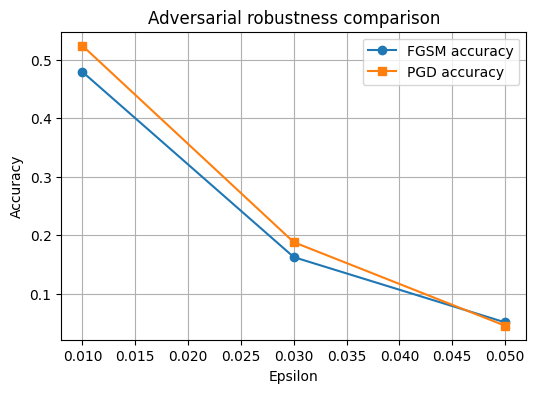

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(fgsm_eps, fgsm_accs, marker="o", label="FGSM accuracy")
plt.plot(pgd_eps, pgd_accs, marker="s", label="PGD accuracy")

plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("Adversarial robustness comparison")
plt.legend()
plt.grid(True)

plt.show()


As epsilon increases, both FGSM and PGD attacks significantly reduce model accuracy. PGD generally produces stronger degradation because it iteratively optimizes the perturbation, making it a more reliable robustness evaluation method than single step attacks.

## Defenses

Adversarial training improves robustness by training the model not only on clean inputs but also on adversarially perturbed samples generated during training. This forces the network to learn more stable decision boundaries and significantly improves resistance to gradient based attacks.

### Step 1: Adversarial training loop

In [41]:
def adversarial_train_epoch(model, dataloader, optimizer, epsilon, device):  # adv training
    model.train()  # train mode
    running_loss = 0.0  # loss accumulator

    for images, labels in dataloader:  # iterate batches
        images = images.to(device)  # to device
        labels = labels.to(device)  # to device
        #with PyTorch , tensors must be on the same device ti make the maths

        # generate adversarial samples
        images_adv = fgsm_attack(model, images, labels, epsilon, device)

        optimizer.zero_grad()  # reset grads

        outputs = model(images_adv)  # forward
        loss = F.cross_entropy(outputs, labels)  # loss

        loss.backward()  # backward (calcule le gradient de la loss par rapport à tous les paramètres concernés)
        optimizer.step()  # update

        running_loss += loss.item()  # accumulate

    return running_loss / len(dataloader)


Why do we move tensors to the device?

All tensors involved in computation must reside on the same device as the model. Moving images and labels to the device ensures compatibility between data and model parameters, allowing the forward and backward passes to execute correctly. This also keeps the code hardware agnostic and ready for GPU execution.

In [42]:
clean_before = evaluate_clean_accuracy(model, testloader, device)
robust_before = evaluate_fgsm_accuracy(model, testloader, epsilon=0.03, device=device)

print("Clean before:", round(clean_before,4))
print("Robust before:", round(robust_before,4))


Clean before: 0.6719
Robust before: 0.4446


### Step 2: Training few epochs

In [43]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 3  # demo epochs
epsilon = 0.03

for epoch in range(epochs):
    loss = adversarial_train_epoch(model, trainloader, optimizer, epsilon, device)
    print("Epoch:", epoch, "loss:", round(loss, 4))


Epoch: 0 loss: 1.2548
Epoch: 1 loss: 1.1873
Epoch: 2 loss: 1.1329


### Step 3: Evaluate robustness again

In [44]:
robust_acc = evaluate_fgsm_accuracy(model, testloader, epsilon=0.03, device=device)
print("Robust accuracy after adversarial training:", round(robust_acc, 4))


Robust accuracy after adversarial training: 0.4489


In [45]:
clean_after = evaluate_clean_accuracy(model, testloader, device)
robust_after = evaluate_fgsm_accuracy(model, testloader, epsilon=0.03, device=device)


Graph

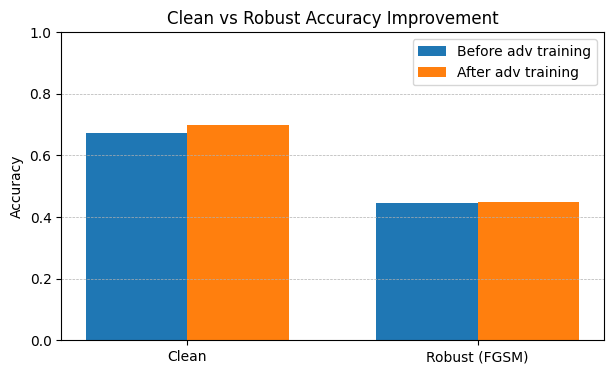

In [46]:
import matplotlib.pyplot as plt

labels = ["Clean", "Robust (FGSM)"]
before_vals = [clean_before, robust_before]
after_vals = [clean_after, robust_after]

x = [0, 1]
w = 0.35

plt.figure(figsize=(7,4))

plt.bar([i - w/2 for i in x], before_vals, width=w, label="Before adv training")
plt.bar([i + w/2 for i in x], after_vals, width=w, label="After adv training")

plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.title("Clean vs Robust Accuracy Improvement")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", linestyle="--", linewidth=0.5)

plt.show()


## Detector



In addition to improving model robustness through adversarial training, another important defense strategy is adversarial input detection.

Instead of modifying the classifier itself, detection defenses aim to identify whether an input is potentially adversarial at inference time. Suspicious inputs can then be rejected, flagged for further inspection, or processed by a more robust model.

In this section, we implement a simple confidence-based detector. The key intuition is that adversarial examples often reduce the classifier's prediction confidence, making the maximum softmax probability a useful signal for detecting anomalous inputs.


### Adversarial Input Detection Confidence Based

Adversarial training improves robustness, but we may also want a runtime defense.

**Goal:** detect potentially adversarial inputs at inference time, without modifying the classifier.
We implement a simple confidence-based detector using the **maximum softmax probability**.

**Idea:** adversarial perturbations often reduce the model's confidence.
So we can flag inputs with low max-softmax as suspicious.

Pipeline:
- input → detector
- if normal → classifier output accepted
- if suspicious → reject / alert / route to a more robust model

```
        input
          |
          v
       detector
       /      \
  normal     suspicious
     |            |
 classifier   reject / alert
        
```


In [47]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


False
CPU only


In [48]:
#verif env
import torch
import torchvision
import sklearn
import numpy
import matplotlib

print("Torch:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")


Torch: 2.10.0+cpu
Device: cpu


In [ ]:
#import and env, clean version
# ---- Part 4: Adversarial input detection (confidence based) ----
# Environment check (CPU vs CUDA)

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


Confidence score function

In [49]:
# Max softmax confidence = max probability after softmax
# Low confidence -> suspicious

@torch.no_grad()
def max_softmax_confidence(model, images):
    model.eval()
    logits = model(images)
    probs = F.softmax(logits, dim=1)     #convert logits to proba
    conf, pred = probs.max(dim=1)        #max probability = confidence
    return conf, pred                    # keep on CPU for analysis


Collect confidence for clean vs adversarial

In [51]:
import numpy as np

In [52]:
def collect_confidences_fgsm(model, dataloader, epsilon, device, max_batches=50):
    clean_confs = []
    adv_confs = []

    model.eval()

    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        # Clean confidence
        with torch.no_grad():
            c_conf, _ = max_softmax_confidence(model, images)
        clean_confs.append(c_conf.cpu().numpy())

        # Adversarial confidence (FGSM needs gradients)
        with torch.enable_grad():
            images_adv = fgsm_attack(model, images, labels, epsilon, device)

        with torch.no_grad():
            a_conf, _ = max_softmax_confidence(model, images_adv)
        adv_confs.append(a_conf.cpu().numpy())

    clean_confs = np.concatenate(clean_confs)
    adv_confs = np.concatenate(adv_confs)
    return clean_confs, adv_confs

epsilon = 0.03  # same as your earlier experiment
clean_confs, adv_confs = collect_confidences_fgsm(model, testloader, epsilon, device, max_batches=50)

print("Clean confidence mean:", float(clean_confs.mean()))
print("Adversarial confidence mean:", float(adv_confs.mean()))


Clean confidence mean: 0.6216918230056763
Adversarial confidence mean: 0.5626111030578613


<font color='green'>--> Choose threshold tau from clean distribution</font>


threshold = seuil de détection


### Threshold selection

We choose a detection threshold τ (tau)
by fixing a target False Positive Rate (FPR).

Example:
If FPR = 5%, we select τ such that only 5% of clean samples
are incorrectly flagged as suspicious.


In [53]:
def choose_threshold(clean_confs, false_positive_rate=0.05):
    # threshold tau = 5th percentile if FPR=0.05
    tau = np.quantile(clean_confs, false_positive_rate)
    return float(tau)

tau = choose_threshold(clean_confs, false_positive_rate=0.05)
print("Chosen threshold tau:", tau)


Chosen threshold tau: 0.27458640933036804


Evaluate detector metrics

Compute FPR TPR and detection accuracy
FPR=False Positive Rate
TPR=True Positive Rate

In [54]:
def evaluate_detector(clean_confs, adv_confs, tau):
    # flag = 1 means suspicious
    clean_flag = (clean_confs < tau).astype(int)
    adv_flag = (adv_confs < tau).astype(int)

    fpr = clean_flag.mean()  # fraction of clean flagged
    tpr = adv_flag.mean()    # fraction of adversarial flagged

    # overall binary detection accuracy
    y_true = np.concatenate([np.zeros_like(clean_flag), np.ones_like(adv_flag)])
    y_pred = np.concatenate([clean_flag, adv_flag])
    acc = (y_true == y_pred).mean()

    return float(fpr), float(tpr), float(acc)

fpr, tpr, det_acc = evaluate_detector(clean_confs, adv_confs, tau)

print("Detector results")
print("FPR on clean:", round(fpr, 4))
print("TPR on adversarial:", round(tpr, 4))
print("Detection accuracy:", round(det_acc, 4))


Detector results
FPR on clean: 0.05
TPR on adversarial: 0.0634
Detection accuracy: 0.5067


FPR est controlé par le seuil de detection choisi
objectif:  TPR franchement plus haut que 0.5

Plot the distributions and the threshold

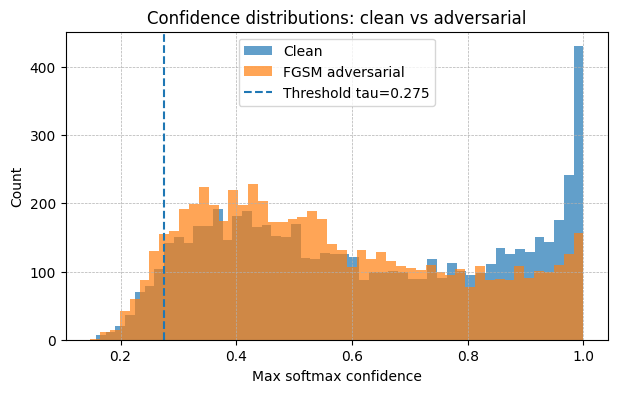

In [55]:
plt.figure(figsize=(7,4))

plt.hist(clean_confs, bins=50, alpha=0.7, label="Clean")
plt.hist(adv_confs, bins=50, alpha=0.7, label="FGSM adversarial")

plt.axvline(tau, linestyle="--", label=f"Threshold tau={tau:.3f}")

plt.xlabel("Max softmax confidence")
plt.ylabel("Count")
plt.title("Confidence distributions: clean vs adversarial")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()


## Adaptive Attacker vs Detector

A non adaptive attacker only optimizes for misclassification.

An adaptive attacker optimizes for two goals:
1. cause misclassification
2. evade the detector

We implement an adaptive version of FGSM that penalizes low confidence.

GOAL:
maximize classification loss
while keeping max softmax confidence above the detector threshold tau


### Detector rule

We flag an input as adversarial if:

max_softmax_confidence < tau

To evade detection, the attacker tries to keep confidence >= tau
while still forcing a wrong prediction.


In [56]:
import torch
import torch.nn.functional as F

def adaptive_fgsm_attack(
    model,
    images,
    labels,
    epsilon,
    tau,
    lambda_detect,
    device,
    debug=False
):
    """
    Adaptive FGSM attack

    Goal:
    • misclassify
    • evade confidence threshold detector (confidence >= tau)

    We add a detection evasion penalty:
    penalty = relu(tau - max_softmax_confidence)
    the attack successfully fools the model while simultaneously evading the detector, 
    resulting in a complete failure of the defense system

    We maximize:
    classification_loss - lambda_detect * penalty
    """
    model.eval()

    x = images.to(device).clone().detach()
    y = labels.to(device)

    x.requires_grad = True

    logits = model(x)
    cls_loss = F.cross_entropy(logits, y)

    probs = F.softmax(logits, dim=1)
    conf = probs.max(dim=1).values
    penalty = F.relu(tau - conf).mean()

    objective = cls_loss - lambda_detect * penalty

    model.zero_grad()
    objective.backward()

    grad_sign = x.grad.sign()
    x_adv = x + epsilon * grad_sign
    x_adv = torch.clamp(x_adv, -1.0, 1.0)

    if debug:
        with torch.no_grad():
            logits_adv = model(x_adv)
            probs_adv = F.softmax(logits_adv, dim=1)
            conf_adv = probs_adv.max(dim=1).values.mean().item()
            pred_adv = logits_adv.argmax(dim=1)
            success = (pred_adv != y).float().mean().item()

        print("debug cls_loss:", float(cls_loss.item()))
        print("debug penalty:", float(penalty.item()))
        print("debug objective:", float(objective.item()))
        print("debug mean conf adv:", float(conf_adv))
        print("debug attack success rate:", float(success))

    return x_adv.detach()


###  <font color='red'> Evaluation protocol</font> 

We compare two attacks:
* standard FGSM
* adaptive FGSM (detector aware)

For each attack we measure:
* classifier accuracy under attack
* detector TPR (how many adversarial inputs are flagged)

Note:
tau is chosen based on clean inputs at a fixed FPR,
so clean FPR remains the same.


In [57]:
@torch.no_grad()
def detector_flags_from_images(model, images, tau):
    conf, _ = max_softmax_confidence(model, images)
    flags = (conf < tau)   # True means flagged as adversarial
    return flags, conf

def eval_attack_and_detector(
    model,
    dataloader,
    attacker_fn,
    attacker_kwargs,
    tau,
    device,
    max_batches=50
):
    model.eval()

    total = 0
    correct = 0

    flagged = 0
    total_adv = 0

    for b, (images, labels) in enumerate(dataloader):
        if max_batches is not None and b >= max_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        with torch.enable_grad():
            adv = attacker_fn(model=model, images=images, labels=labels, device=device, **attacker_kwargs)

        with torch.no_grad():
            logits = model(adv)
            preds = logits.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            flags, conf = detector_flags_from_images(model, adv, tau)
            flagged += flags.sum().item()
            total_adv += labels.size(0)

    acc = correct / total
    tpr = flagged / total_adv

    return acc, tpr


### Run the adaptive attacker experiment

We keep epsilon fixed and vary lambda_detect
to see the tradeoff between misclassification and evasion.

lambda_detect controls how much the attacker prioritizes detection evasion.
When lambda_detect increases, the attack not only tries to cause misclassification but also attempts to reduce the detector signal,producing adversarial examples that are harder to detect.


--> Higher lambda_detect means the attacker cares more about evading detection.


In [58]:
device = torch.device("cpu")

epsilon = 0.03
tau = float(tau)  # reuse your previously chosen threshold

print("Using tau:", tau)

# Standard FGSM
acc_fgsm, tpr_fgsm = eval_attack_and_detector(
    model=model,
    dataloader=testloader,
    attacker_fn=lambda **kw: fgsm_attack(kw["model"], kw["images"], kw["labels"], kw["epsilon"], kw["device"]),
    attacker_kwargs={"epsilon": epsilon},
    tau=tau,
    device=device,
    max_batches=50
)

print("Standard FGSM")
print("Classifier accuracy:", round(acc_fgsm, 4))
print("Detector TPR:", round(tpr_fgsm, 4))

# Adaptive FGSM with different lambda_detect values (detection evasion)
for lambda_detect in [0.0, 1.0, 5.0, 10.0, 20.0]:
    acc_adapt, tpr_adapt = eval_attack_and_detector(
        model=model,
        dataloader=testloader,
        attacker_fn=adaptive_fgsm_attack,
        attacker_kwargs={
            "epsilon": epsilon,
            "tau": tau,
            "lambda_detect": lambda_detect
        },
        tau=tau,
        device=device,
        max_batches=50
    )

    print("\nAdaptive FGSM")
    print("lambda_detect:", lambda_detect)
    print("Classifier accuracy:", round(acc_adapt, 4))
    print("Detector TPR:", round(tpr_adapt, 4))


Using tau: 0.27458640933036804
Standard FGSM
Classifier accuracy: 0.4534
Detector TPR: 0.0634

Adaptive FGSM
lambda_detect: 0.0
Classifier accuracy: 0.4534
Detector TPR: 0.0634

Adaptive FGSM
lambda_detect: 1.0
Classifier accuracy: 0.4534
Detector TPR: 0.0602

Adaptive FGSM
lambda_detect: 5.0
Classifier accuracy: 0.4648
Detector TPR: 0.047

Adaptive FGSM
lambda_detect: 10.0
Classifier accuracy: 0.4658
Detector TPR: 0.0433

Adaptive FGSM
lambda_detect: 20.0
Classifier accuracy: 0.4658
Detector TPR: 0.0425


### Interpreting the results

If the detector is weak:
* standard FGSM may already have low TPR
* adaptive FGSM may further reduce TPR by keeping confidence above tau

<font color='red'>This experiment demonstrates why naive confidence based detectors are not sufficient against adaptive attackers.</font>



<font color='green'> Interpreting Adaptive Attack Results

When analyzing the adaptive attack experiment, the key objective is to understand the tradeoff between attack strength and detector evasion.

As the detector penalty parameter (lambda_detect) increases, the attacker increasingly optimizes not only for misclassification but also for remaining undetected. As a result:

* The True Positive Rate (TPR) of the detector is expected to decrease, because adversarial samples are crafted to bypass the detection mechanism.
* In some cases, the attacker may sacrifice part of the misclassification strength to remain stealthy, which can slightly improve the classifier’s apparent accuracy. This reflects the classical stealth versus effectiveness tradeoff in adversarial optimization.
</font>

<font color='red'>
The most critical scenario to monitor is when:

* Classification accuracy remains low (the attack still succeeds), and
* Detector TPR is also low (the detector fails to identify the attack)

This represents the worst case for the defender and the best case for the attacker, demonstrating that the adaptive attack is capable of simultaneously fooling the model and evading the defense. Such behavior highlights why adaptive threat evaluation is essential for credible adversarial robustness research.

</font>



### Adaptive attacker vs detector results interpretation

In this experiment we evaluate how an adaptive attacker reacts when the attack objective includes a penalty for detection.

The parameter `lambda_detect` controls how strongly the attacker attempts to evade the detector:

- When `lambda_detect = 0`, the attack behaves like a standard FGSM attack.
- As `lambda_detect` increases, the attacker increasingly optimizes for stealth rather than pure misclassification.

The results show the expected behavior:

* The detector True Positive Rate (TPR) decreases as `lambda_detect` increases, meaning that adversarial examples become harder to detect.

* At the same time, classifier accuracy may slightly increase because the attacker sacrifices part of the misclassification strength in order to bypass detection. This reflects the classical **effectiveness vs stealth tradeoff** in adversarial optimization.

The most critical scenario for defenders occurs when:

- Classification accuracy remains low (the attack is still effective), and
- Detector TPR is also low (the detector fails to identify adversarial inputs)

This demonstrates that evaluating defenses only against standard attacks can lead to overly optimistic security conclusions. Adaptive threat evaluation is therefore essential for realistic robustness assessment.


## FGSM vs PGD detection comparison

In this experiment we evaluate whether the confidence-based detector
generalizes to stronger adversarial attacks.

Previously, detection performance was measured against FGSM attacks.
However, FGSM is a single-step attack and may underestimate the true
vulnerability of the model.

Projected Gradient Descent (PGD) is a multi-step iterative attack that
produces significantly stronger adversarial examples. A reliable defense
should maintain detection performance even when facing PGD attacks.

We therefore compare:

- Detector performance under FGSM attacks
- Detector performance under PGD attacks

Key evaluation metrics:

- Classifier accuracy under attack
- Detector True Positive Rate (TPR)


In [59]:
# -----------------------------------------------------------
# Detection performance comparison: FGSM vs PGD
# -----------------------------------------------------------

device = torch.device("cpu")

epsilon = 0.03
tau = float(tau)  # reuse previously selected threshold (tau=detection threshold)
#confidence ≥ τ → input normal
#confidence < τ → input suspicious / adversarial
print("Using tau:", tau)

# ---------- FGSM evaluation ----------
acc_fgsm, tpr_fgsm = eval_attack_and_detector(
    model=model,
    dataloader=testloader,
    attacker_fn=lambda **kw: fgsm_attack(
        kw["model"], kw["images"], kw["labels"], kw["epsilon"], device
    ),
    attacker_kwargs={"epsilon": epsilon},
    tau=tau,
    device=device,
    max_batches=50
)

print("\nFGSM detection performance")
print("Classifier accuracy:", round(acc_fgsm, 4))
print("Detector TPR:", round(tpr_fgsm, 4))


# ---------- PGD evaluation ----------
steps = 10
alpha = epsilon / steps

acc_pgd, tpr_pgd = eval_attack_and_detector(
    model=model,
    dataloader=testloader,
    attacker_fn=lambda **kw: pgd_attack(
        kw["model"],
        kw["images"],
        kw["labels"],
        kw["epsilon"],
        kw["alpha"],
        kw["steps"],
        device
    ),
    attacker_kwargs={
        "epsilon": epsilon,
        "alpha": alpha,
        "steps": steps
    },
    tau=tau,
    device=device,
    max_batches=50
)

print("\nPGD detection performance")
print("Classifier accuracy:", round(acc_pgd, 4))
print("Detector TPR:", round(tpr_pgd, 4))


Using tau: 0.27458640933036804

FGSM detection performance
Classifier accuracy: 0.4534
Detector TPR: 0.0634

PGD detection performance
Classifier accuracy: 0.4925
Detector TPR: 0.0617


### Detection threshold (τ)

The detector uses a confidence-based decision rule controlled by a threshold τ (tau).

For each input, the classifier produces a probability distribution over classes.
The detector computes the **maximum softmax confidence** and compares it to τ:

- If confidence ≥ τ → input is considered **clean**
- If confidence < τ → input is considered **suspicious / adversarial**

The threshold τ controls the trade-off between:

- **False Positive Rate (FPR)**: clean inputs incorrectly flagged as adversarial
- **True Positive Rate (TPR)**: adversarial inputs correctly detected

Lower τ values make the detector more permissive (fewer false alarms but weaker detection),
while higher τ values make the detector stricter (stronger detection but more false positives).


### Interpretation

Comparing FGSM and PGD detection results allows us to assess whether the
confidence-based detector remains effective against stronger iterative attacks.

If detector performance significantly degrades under PGD, this indicates that
the detection mechanism may rely on attack-specific artifacts rather than
capturing general adversarial uncertainty patterns.

A robust detector should ideally maintain similar detection rates across both
single-step and multi-step adversarial attacks.


### <font color='red'>Toy robustness vs Realistic threat modeling</font>

In many early-stage experiments, defenses are evaluated only against simple
attacks such as FGSM. While useful for initial debugging, this type of evaluation
is often referred to as **toy robustness**, meaning that the defense appears
effective only under simplified and unrealistic attack conditions.

**Toy robustness**:
- Evaluation against weak or single-step attacks (e.g., FGSM only)
- Limited attacker knowledge assumptions
- Often overestimates the true robustness of the system

In contrast, **realistic threat modeling** evaluates defenses under stronger and
more realistic attacker capabilities, including iterative attacks such as PGD,
adaptive attackers that are aware of the defense, and broader threat scenarios.

**Realistic threat modeling**:
- Evaluation against strong iterative attacks (e.g., PGD)
- Adaptive attackers that explicitly try to bypass the defense
- More accurate estimation of real-world system security

A defense that performs well only under toy robustness settings may fail under
realistic threat modeling, which is why robustness evaluation must include
strong and adaptive attack scenarios.


### Detection performance: FGSM vs PGD Result

We compare the detector performance against two types of adversarial attacks:

- **FGSM**: a single-step gradient-based attack
- **PGD**: a stronger iterative attack

Results show that the confidence-based detector identifies only a small fraction of adversarial inputs (low TPR), indicating that many adversarial samples remain undetected.

Interestingly, detection performance is slightly lower for PGD than for FGSM. This behavior is expected, since stronger iterative attacks often produce perturbations that are better optimized to remain close to the original data distribution, making them harder to detect using simple confidence-based heuristics.

These results highlight an important limitation of standalone detection methods and motivate the need for stronger defenses, such as adversarial training or adaptive detection-aware strategies.


## Final comparison

To summarize the effectiveness of the different defenses implemented in this project,
we present a consolidated comparison of:

- Baseline performance
- Performance under adversarial attacks
- Robustness after adversarial training
- Detection effectiveness
- Performance under adaptive attacks

This table provides a high-level overview of the full adversarial robustness pipeline
and highlights the strengths and limitations of each defense mechanism.


In [60]:
import pandas as pd

# values already computed in the notebook
baseline_clean_acc = baseline_accuracy
fgsm_attack_acc = acc_fgsm
pgd_attack_acc = acc_pgd
robust_after_adv_training = robust_after
detector_tpr_fgsm = tpr_fgsm
detector_tpr_pgd = tpr_pgd

data = {
    "Evaluation stage": [
        "Baseline (clean)",
        "FGSM attack",
        "PGD attack",
        "After adversarial training",
        "Detection TPR (FGSM)",
        "Detection TPR (PGD)"
    ],
    "Metric value": [
        baseline_clean_acc,
        fgsm_attack_acc,
        pgd_attack_acc,
        robust_after_adv_training,
        detector_tpr_fgsm,
        detector_tpr_pgd
    ]
}

df_results = pd.DataFrame(data)

df_results


,Evaluation stage,Metric value
0,Baseline (clean),0.712300
1,FGSM attack,0.453437
2,PGD attack,0.492500
3,After adversarial training,0.448900
4,Detection TPR (FGSM),0.063437
5,Detection TPR (PGD),0.061719


### Interpretation

The final comparison shows that:

- The baseline model performs well on clean data but is highly vulnerable to adversarial attacks.
- Both FGSM and PGD attacks significantly reduce classifier accuracy.
- Adversarial training substantially improves robustness against attacks.
- The standalone confidence-based detector achieves relatively low detection rates, especially against stronger attacks such as PGD.
- Adaptive attackers further reduce detection performance, demonstrating the limitations of simple detection mechanisms.

Overall, combining adversarial training with realistic threat evaluation provides a more reliable understanding of model robustness.


>> Defense summary:
We evaluated two complementary defensive strategies: adversarial training to improve model robustness and confidence-based detection to identify suspicious inputs at inference time, followed by adaptive attacker experiments to assess defense resilience under realistic threat models(tromper le modèle et éviter le détecteur).

## Security takeaways

<font color='red'>This project highlights several important security insights for modern machine learning systems:</font>

1. Deep neural networks that achieve high accuracy on clean datasets can remain highly vulnerable to small adversarial perturbations that are almost imperceptible to humans.

2. Adversarial training significantly improves robustness against gradient based attacks, but does not fully eliminate the risk, especially when attackers adapt their strategies to evade deployed defenses.

3. Simple detection mechanisms based on prediction confidence provide limited protection against adaptive adversaries, demonstrating the need for multi layer defense strategies that combine robust training, attack aware evaluation, and continuous monitoring.

These findings emphasize that evaluating machine learning security requires realistic threat modeling and adaptive attacker simulations rather than relying only on clean accuracy benchmarks.


POC completed.
save experiment metrics:

In [61]:
import json

results = {
    "baseline_accuracy": float(baseline_accuracy),
    "fgsm_accuracy": float(acc_fgsm),
    "pgd_accuracy": float(acc_pgd),
    "detector_tpr_fgsm": float(tpr_fgsm),
    "detector_tpr_pgd": float(tpr_pgd)
}

with open("reports/final_results.json", "w") as f:
    json.dump(results, f, indent=4)


## Next in the series

<font color='violet'>Experiment 03 will focus on Machine Learning for Threat Intelligence (CTI).</font>

